# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Angelika Revalina Rismawati
- **Email:** CDCC006D6X2303@student.devacademy.id
- **ID Dicoding:** angelika_revalina

## Menentukan Pertanyaan Bisnis

- Bagaimana proporsi kontribusi pengguna casual dan registered terhadap total penyewaan sepeda selama periode tahun 2011-2012?
- Bagaimana pola rata-rata jumlah penyewaan sepeda berdasarkan hari dalam seminggu (Senin-Minggu) selama periode data tahun 2011-2012?
- Bagaimana perbedaan rata-rata jumlah penyewaan sepeda pada berbagai kondisi cuaca seperti cerah, berawan, dan hujan ringan selama periode tahun 2011-2012?

## Import Semua Packages/Library yang Digunakan

In [55]:
from google.colab import drive
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

## Data Wrangling

### Gathering Data

In [56]:
#Membaca file day.csv
drive.mount('/content/drive')
day_df = pd.read_csv('/content/drive/MyDrive/Bike_sharing_dataset/day.csv')

#Melihat 5 baris pertama
day_df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


# **Insight:**
Dari 5 data  teratas yang telah ditampilkan, maka insight yang diperoleh adalah:
- Data ini mencakup penyewaan sepeda per hari mulai dari tanggal 1 Januari 2011 hingga seterusnya, dimana pada tanggal tersebut adalah hari Sabtu (weekday = 6), kemudian tanggal 2 adalah hari minggu, lalu senin, dst.
- Dari 5 hari pertama, jumlah penyewa paling sedikit adalah pada hari Minggu, yakni sebanyak 801 orang. Mungkin hal ini terjadi karena hari minggu banyak orang yang istirahat di rumah setelah agenda tahun baru (1 Januari). Diperhatikan bahwa, pada hari kerja ternyata lebih banyak yang menyewa sepeda. Hal ini bisa untuk bahan analisis selanjutnya.

### Assessing Data

In [57]:
#Untuk cek struktur data
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


# **Insight:**
- Pada struktur data tersebut, jumlah data day.csv adalah 731 baris dengan jumlah kolom sebanyak 16. Semua kolom memiliki jumlah data yang sama, yaitu sebanyak 731 data.
- Namun, tipe data pada kolom dteday berupa objek, sedangkan itu menunjukkan tanggal, bulan dan tahun berapa, sehingga selanjutnya perlu diperbaiki tipe datanya.

In [58]:
#Cek statistika deskriptif
day_df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


# **Insight:**
- Melakukan perintah describe() untuk melihat statistik deskriptif data penyewaan sepeda per hari. Dari dataset tersebut, menggambarkan data  per hari dalam 2 tahun penuh, yakni 365+366 hari (dimana tahun 2012 merupakan tahun kabisat).
-  Selanjutnya, diperoleh rata-rata setiap kolomnya. Yakni, terdapat rata-rata 4.504 orang yang menyewa perharinya. Variasi yang diperoleh cukup besar, yakni 1.937 yang menunjukkan ada hari sepi dan ramai. Hari paling sepi ketika hanya terdapat 22 penyewa, dan hari paling ramai mencapai 8.714 penyewa.

In [59]:
#Cek apakah ada missing value
day_df.isna().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
holiday,0
weekday,0
workingday,0
weathersit,0
temp,0


# **Insight:**
- Dari pengecekan missing value, diperoleh bahwa tidak ada data yang hilang, artinya data ini sudah lengkap hingga baris dan kolom terakhir.

In [60]:
#Cek apakah ada ducplicate data
day_df.duplicated().sum()

np.int64(0)

# **Insight:**
- Setelah pengecekan duplikasi data, dapat diperoleh bahwa tidak ada data yang duplikat, sehingga setiap baris menunjukkan data yang unik dan tidak sama satu sama lain.

Karena data ini sudah cukup bersih dan siap, sehingga tahap selanjutnya akan dilakukan tahap cleaning data.

### Cleaning Data

In [61]:
#Untuk menghilangkan duplicate data
day_df.drop_duplicates(inplace=True)

#Cek apakah masih ada duplikasi data
print(f'Jumlah duplikasi: {day_df.duplicated().sum()} ')

Jumlah duplikasi: 0 


# **Insight:**
- Pada tahap assesing data, ditemukan bahwa tidak ada data yang duplikat, namun untuk meyakinkan hal tersebut, tetap dilakukan penghapusan pada data yang duplikat supaya meyakinkan tidak ada duplikasi data.

In [62]:
#Untuk menangani missing value
day_df.isna().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
holiday,0
weekday,0
workingday,0
weathersit,0
temp,0


# **Insight:**

- Diperoleh bahwa tidak ada data yang hilang (missing value), sehingga tidak perlu dilakukan untuk pembersihan tabel.

In [63]:
#Memperbaiki tipe data pada kolom dteday
datetime_columns = ['dteday']

for column in datetime_columns:
  day_df[column] = pd.to_datetime(day_df[column])


#Cek tipe data setelah diperbaiki
day_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     731 non-null    int64         
 1   dteday      731 non-null    datetime64[ns]
 2   season      731 non-null    int64         
 3   yr          731 non-null    int64         
 4   mnth        731 non-null    int64         
 5   holiday     731 non-null    int64         
 6   weekday     731 non-null    int64         
 7   workingday  731 non-null    int64         
 8   weathersit  731 non-null    int64         
 9   temp        731 non-null    float64       
 10  atemp       731 non-null    float64       
 11  hum         731 non-null    float64       
 12  windspeed   731 non-null    float64       
 13  casual      731 non-null    int64         
 14  registered  731 non-null    int64         
 15  cnt         731 non-null    int64         
dtypes: datetime64[ns](1), floa

# **Insight:**

- Dilakukan perbaikan tipe data pada kolom dtype, karena sebelumnya bertipe objek. Dtype menunjukkan waktu (tanggal, bulan dan tahun) sehingga typenya harus diperbaiki menggunakan date_time. Selanjutnya perlu di cek kembali apakah tipe data yang sudah diperbaiki itu betul, dan untuk meyakinkan kembali.

In [64]:
#Untuk melihat 5 baris pertama
day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


# **Insight:**

- Dari 5 data teratas dapat dilihat bahwa tipe data dari dteday sudah berhasil dirubah.

## Exploratory Data Analysis (EDA)

### Explore Data day_df

In [65]:
day_df.describe(include="all")

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2012-01-01 00:00:00,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
min,1.000000,2011-01-01 00:00:00,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2011-07-02 12:00:00,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,2012-01-01 00:00:00,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,2012-07-01 12:00:00,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,2012-12-31 00:00:00,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000
std,211.165812,NaN,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452


# **Insight:**
- Melakukan perintah describe() untuk melihat statistik deskriptif data penyewaan sepeda per hari. Dari dataset tersebut, menggambarkan data  per hari dalam 2 tahun penuh, yakni 365+366 hari (dimana tahun 2012 merupakan tahun kabisat).
-  Selanjutnya, diperoleh rata-rata setiap kolomnya. Yakni, terdapat rata-rata 4.504 orang yang menyewa perharinya. Variasi yang diperoleh cukup besar, yakni 1.937 yang menunjukkan ada hari sepi dan ramai. Hari paling sepi ketika hanya terdapat 22 penyewa, dan hari paling ramai mencapai 8.714 penyewa.

In [66]:
#untuk cek bahwa tanggalnya unik (tidak duplicate)
day_df.dteday.is_unique

True

# **Insight**
- Tidak ada data tanggal yang terinput double

In [67]:
#Agfregasi
day_df.groupby(['yr','mnth'])[['registered','casual']].sum()

registered  casual
yr mnth                    
0  1          35116    3073
   2          41973    6242
   3          51219   12826
   4          72524   22346
   5         104771   31050
   6         112900   30612
   7         104889   36452
   8         107849   28842
   9         100873   26545
   10         98289   25222
   11         86573   15594
   12         78875    8448
1  1          87775    8969
   2          94416    8721
   3         133257   31618
   4         135768   38456
   5         151630   44235
   6         159536   43294
   7         161902   41705
   8         171306   43197
   9         174795   43778
   10        164303   34538
   11        131655   21009
   12        110468   13245

# **Insight**
- Pada tahun 2011, jumlah penyewa terbanyak untuk pengguna registered pada bulan 6 (Juni), sedangkan untuk pengguna casual pada bulan 7 (Juli).
- Pada tahun 2012, jumlah penyewa terbanyak untuk pengguna registered pada bulan 9 (September), sedangkan untuk pengguna casual pada bulan 5 (Mei).
- Jumlah penyewa mengalami puncak penyewaan pada bulan Mei-September, hal ini bisa karena pada bulan tersebut mengalami musim panas.

### Analisis Korelasi

In [68]:
#Untuk analisis korelasi
day_df.corr()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
instant,1.000000,1.000000,0.412224,0.866025,0.496702,0.016145,-0.000016,-0.004337,-0.021477,0.150580,0.152638,0.016375,-0.112620,0.275255,0.659623,0.628830
dteday,1.000000,1.000000,0.412224,0.866025,0.496702,0.016145,-0.000016,-0.004337,-0.021477,0.150580,0.152638,0.016375,-0.112620,0.275255,0.659623,0.628830
season,0.412224,0.412224,1.000000,-0.001844,0.831440,-0.010537,-0.003080,0.012485,0.019211,0.334315,0.342876,0.205445,-0.229046,0.210399,0.411623,0.406100
yr,0.866025,0.866025,-0.001844,1.000000,-0.001792,0.007954,-0.005461,-0.002013,-0.048727,0.047604,0.046106,-0.110651,-0.011817,0.248546,0.594248,0.566710
mnth,0.496702,0.496702,0.831440,-0.001792,1.000000,0.019191,0.009509,-0.005901,0.043528,0.220205,0.227459,0.222204,-0.207502,0.123006,0.293488,0.279977
holiday,0.016145,0.016145,-0.010537,0.007954,0.019191,1.000000,-0.101960,-0.253023,-0.034627,-0.028556,-0.032507,-0.015937,0.006292,0.054274,-0.108745,-0.068348
weekday,-0.000016,-0.000016,-0.003080,-0.005461,0.009509,-0.101960,1.000000,0.035790,0.031087,-0.000170,-0.007537,-0.052232,0.014282,0.059923,0.057367,0.067443
workingday,-0.004337,-0.004337,0.012485,-0.002013,-0.005901,-0.253023,0.035790,1.000000,0.061200,0.052660,0.052182,0.024327,-0.018796,-0.518044,0.303907,0.061156
weathersit,-0.021477,-0.021477,0.019211,-0.048727,0.043528,-0.034627,0.031087,0.061200,1.000000,-0.120602,-0.121583,0.591045,0.039511,-0.247353,-0.260388,-0.297391
temp,0.150580,0.150580,0.334315,0.047604,0.220205,-0.028556,-0.000170,0.052660,-0.120602,1.000000,0.991702,0.126963,-0.157944,0.543285,0.540012,0.627494


# **Insight:**
Dari tabel korelasi tersebut, dapat diperoleh pengetahuan bahwa:
- Total penyewa (cnt) lebih dominan pada  pengguna member (Registered) daripada pengguna biasa (casual), hal ini diperoleh dari korelasi cnt dan registered sebesar 0.945, sedangkan hubungan cnt dan casual sebesar 0.673 (lebih kecil).
- Faktor cuaca yang paling memengaruhi penyewaan adalah suhu dan cuaca, hal ini dapat ditunjukkan pada korelasi antara cnt dengan temp sebesar 0.627, cnt dengan atemp sebesar 0.631. Apabila suhu semakin hangat, maka semakin baik.
- Usaha penyewaan ini memiliki peningkatan jumlah penyewaan pada tahun 2012, hal ini dapat ditunjukkan pada korelasi antara cnt dengan yr yaitu sebesar 0.567.
- Tidak ada perbedaan antara penyewaan pada hari kerja dan akhir pekan. Hal ini dapat ditunjukkan pada besarnya korelasi antara cnt dengan workingday yaitu 0.06, cnt dengan weekday yaitu (0.07), dan cnt dengan holiday yaitu -0.07, dimana ketiganya mmendekati nol.
- Pengguna member (registered) lebih sering menyewa pada hari kerja, hal ini dapat dilihat pada korelasi antara registered dengan workingday yaitu sebesar 0.30, dibandingkan dengan korelasi antara casual dan workingday sebesar -0.52 (tidak ada korelasi).

## Visualization & Explanatory Analysis

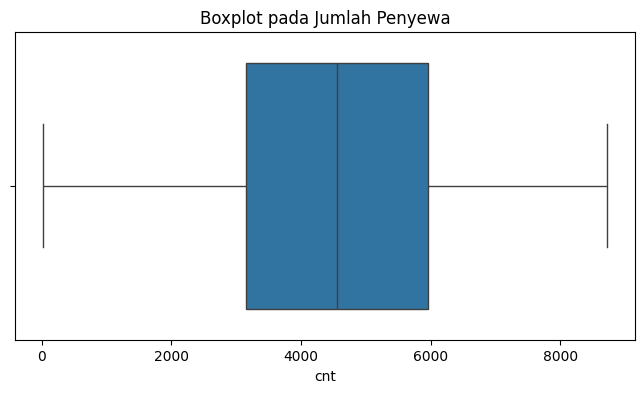

In [69]:
#Boxplot
plt.figure(figsize=(8,4))
sns.boxplot(x=day_df["cnt"])
plt.title("Boxplot pada Jumlah Penyewa")
plt.show()

# **Insight**
- Dari boxplot tersebut, tidak ditemukan outliers pada kolom jumlah penyewa (cnt). Sebaran data menunjukkan bahwa sebagian besar nilai cnt berada pada rentang 3000 hhingga 6000 penyewa. Hal ini dapat disimpulkan bahwa data relatif stabil meskipun terdapat variasi pada jumlah penyewa antar hari.

## Pertanyaan 1: Bagaimana proporsi kontribusi pengguna casual dan registered terhadap total penyewaan sepeda selama periode tahun 2011-2012?

In [70]:
#Aggregasi data
total_pengguna = day_df[["casual", "registered"]].sum()

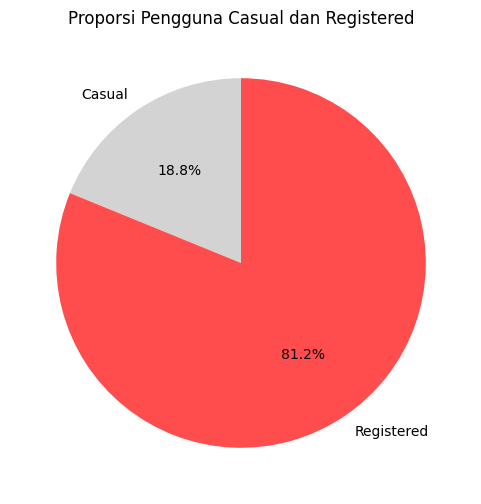

In [71]:
#plot diagram lingkaran
labels = ["Casual", "Registered"]
colors = ["#D3D3D3", "#FF4C4C"]

plt.figure(figsize=(6,6))
plt.pie(
    total_pengguna.values,
    labels=labels,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90
)
plt.title("Proporsi Pengguna Casual dan Registered")
plt.show()

# **Insight**
- Dari diagram lingkaran tersebut, dapat disimpulkan bahwa jumlah penyewa terbanyak/ paling sering menyewa adalah pengguna terdaftar (Registered). yaitu sebanyak 81.2% Hal ini dapat menjadi pertimbangan untuk perusahaan dalam meningkatkan strategi promosi bisnis bagi pengguna baru maupun pengguna terdaftar.

### Pertanyaan 2: Bagaimana pola rata-rata jumlah penyewaan sepeda berdasarkan hari dalam seminggu (Senin-Minggu) selama periode data tahun 2011-2012?


In [72]:
#Agregasi data
byday_df = day_df.groupby('weekday')['cnt'].mean().reset_index()

hari_map = {
    0: "Minggu",
    1: "Senin",
    2: "Selasa",
    3: "Rabu",
    4: "Kamis",
    5: "Jumat",
    6: "Sabtu"
}

byday_df["weekday"] = byday_df["weekday"].map(hari_map)
byday_df.columns = ['Hari', 'Rata_rata_penyewa']

/tmp/ipykernel_4654/4044863730.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


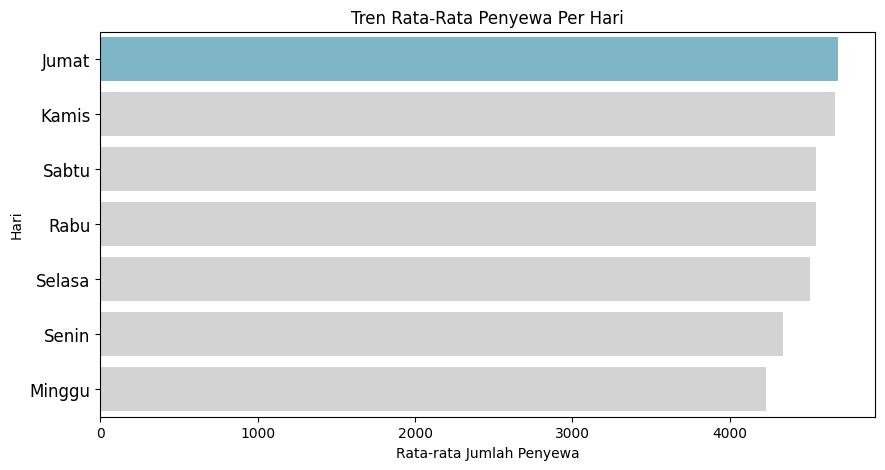

In [73]:
#plot diagram
plt.figure(figsize=(10, 5))
warna = ["#72BCD4", "#D3D3D3", "#D3D3D3", "#D3D3D3", "#D3D3D3", "#D3D3D3", "#D3D3D3"]

sns.barplot(
    x="Rata_rata_penyewa",
    y="Hari",
    data=byday_df.sort_values(by='Rata_rata_penyewa', ascending=False),
    palette=warna
)
plt.title("Tren Rata-Rata Penyewa Per Hari")
plt.xlabel("Rata-rata Jumlah Penyewa")
plt.ylabel("Hari")
plt.tick_params(axis='y', labelsize=12)
plt.show()

**Insight:**
- Dapat diperoleh bahwa jumlah penyewa terbanyak adalah pada hari Jumat, dan jumlah penyewa terendah adalah pada hari Minggu. Hal ini bisa menjadi wawasan untuk perusahaan, bahwa ternyata pada weekend tidak selalu banyak penyewa, namun justru pada hari kerja, sepeda lebih banyak digunakan (disewa). Hal ini juga menunjukkan bahwa sepeda lebih banyak digunakan untuk aktivitas rutin seperti bekerja.
- Perusahaan dapat meningkatkan strategi permintaan di hari sepi seperti promo khusus di hari Minggu atau diskon pada paket wisata. Selain itu, perusahaan juga fokus mempertahankan kualitas bisnis untuk pengguna terdaftar seperti poin atau promo khusus

### Pertanyaan 3: Bagaimana perbedaan rata-rata jumlah penyewaan sepeda pada berbagai kondisi cuaca seperti cerah, berawan, dan hujan ringan selama periode tahun 2011-2012?

In [74]:
#Agregasi data
weather_df = day_df.groupby("weathersit")["cnt"].agg(['mean', 'sum', 'count']).reset_index()
weather_df.columns = ["Cuaca", "Rata_rata", "Total", "Jumlah_Data"]

weather_map = {
    1: "Cerah",
    2: "Berawan",
    3: "Hujan ringan",
    4: "Hujan lebat",
}

weather_df["Cuaca"] = weather_df["Cuaca"].map(weather_map)

/tmp/ipykernel_4654/2983193530.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


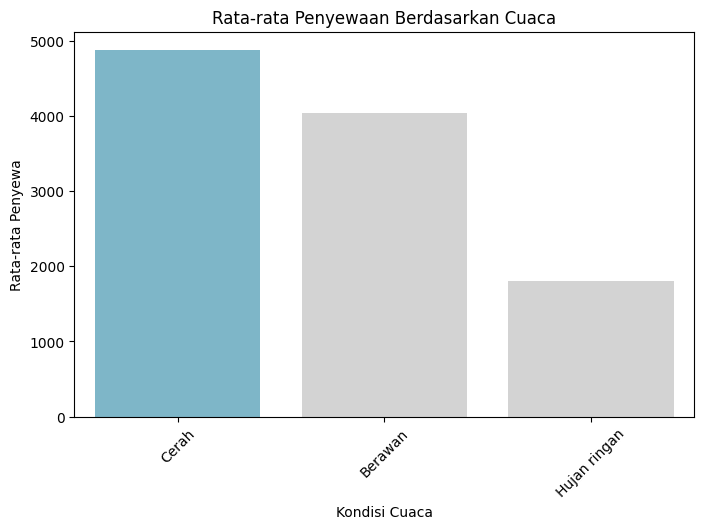

In [75]:
plt.figure(figsize=(8,5))
max_cuaca = weather_df.loc[weather_df['Rata_rata'].idxmax(), 'Cuaca']
colors = [
    "#72BCD4" if cuaca == max_cuaca else "#D3D3D3"
    for cuaca in weather_df['Cuaca']
]

sns.barplot(
    x="Cuaca",
    y="Rata_rata",
    data=weather_df,
    palette=colors,
    order=weather_df.sort_values("Rata_rata", ascending=False)["Cuaca"]
)

plt.title("Rata-rata Penyewaan Berdasarkan Cuaca")
plt.xlabel("Kondisi Cuaca")
plt.ylabel("Rata-rata Penyewa")
plt.xticks(rotation=45)

plt.show()

**Insight:**
- Kondisi cuca ternyata sangat berpengaruh terhadap jumlah penywa, seperti jumlah penyewa terbanyak ketika cuaca cerah. Dapat dilihat juga bahwa pada cuaca hujan ringan, jumlah penyewa menurun drastis. Hal ini dapat disebabkan karena orang-orang enggan untuk keluar rumah atau bersepeda meskipun hanya gerimis. Perusahaan bisa mengurangi stok sepeda, atau diganti dengan melakukan maintenance pada sepeda lainnya.

## Analisis Lanjutan (Opsional)

In [76]:
#Melakukan binning berdasarkan suhu
def temp_binning(temp):
  if temp < 0.2:
    return 'sangat dingin'
  elif temp < 0.4:
    return 'dingin'
  elif temp < 0.6:
    return 'hangat'
  elif temp < 0.8:
    return 'panas'
  else:
    return 'sangat panas'

day_df['temp_category'] = day_df['temp'].apply(temp_binning)

<Axes: xlabel='temp', ylabel='cnt'>

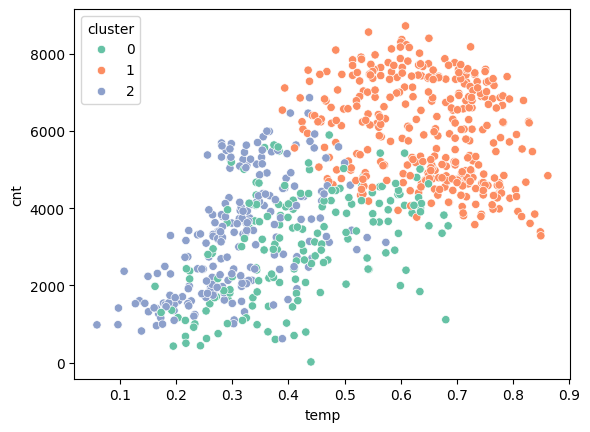

In [77]:
#Melakukan clustering
fitur = day_df[['cnt', 'temp', 'hum']]

scal = StandardScaler()
fitur_scaled = scal.fit_transform(fitur)

#clustering
kmeans = KMeans(n_clusters=3, random_state=42)
day_df['cluster'] = kmeans.fit_predict(fitur_scaled)

sns.scatterplot(
    x="temp",
    y="cnt",
    hue="cluster",
    data=day_df,
    palette="Set2"
)

# **Insight:**
- Dari hasil clustering, dapat dilihat bahwa cluster 0 menunjukkan penyewa dengan suhu rendah dengan kelembapan tinggi, cluster 1 menunjukkan jumlah penyewa dengan suhu dan kelembapan sedang, cluster 2 menunjukkan jumlah penyewa dengan suhu tinggi dan kelembapan rendah.
- Semakin tinggi suhu dengan tingkat kelembapan rendah, maka jumlah penyewa cenderung menurun karena kondisi udara yang tidak nyaman untuk beraktivitas di luar. Sedangkan pada tingkat kelembapan sedang dengan suhu hangat, jumlah penyewa cenderung lebih tinggi.

## Conclusion

- Kontribusi pelanggan pada jumlah penyewaan sepeda tahun 2011-2012 didominasi oleh pengguna registered daripada pengguna casual. Hal ini menunjukkan bahwa sebagian besar penyewaan dilakukan oleh pengguna member (registered), sehingga sepeda lebih banyak bersifat rutin dibandingkan sesekali. Perusahaan dapat menggunakan promo tambahan di hari tertentu atau suatu poin ketika sudah menyewa supaya pengguna member tetap setia.

- Rata-rata jumlah penyewa terbanyak berdasarkan hari dalam seminggu pada tahun 2011-2012 adalah pada hari Jumat, diikuti Kamis dan kemudian Sabtu. Namun, pada hari minggu yang merupakan weekend, justru merupakan hari dengan jumlah penyewa terendah. Dari hal ini, perusahaan dapat menambah stok khusus pada hari ramai seperti Jumat, atau pada hari kerja. Selain itu, perusahaan juga dapat membuka tempat penyewaan yang lebih banyak dan strategis. Karena pada hari minggu terdapat penurunan jumlah sewa sepeda, maka perusahaan dapat melakukan maintenance di hari tersebut, atau mengadakan promo paket wisata untuk keluarga atau diskon tertentu.

- Cuaca sangat berpengaruh terhadap rata-rata jumlah penyewa pada tahun 2011-2012. Khususnya pada cuaca cerah, jumlah penyewa justru lebih banyak, lalu sedikit menurun ketika cuaca berawan, dan menurun drastis ketika cuaca hujan ringan seperti gerimis. Dari hal ini, perusahaan dapat melakukan perpanjangan waktu  operasional pada saat cuaca cerah dan jam kerja. Selain itu, perusahaan juga bisa menambahkan stok sepeda ketika cuaca cerah. Untuk cuaca berawan, perusahaan dapat mengadakan promosi ringan untuk menarik penyewa dengan menyediakan sewa jas hujan dengan harga murah.

## Simpan berkas

In [78]:
#Menyimpan berkas data yang telah dibersihkan
day_df.to_csv("day_data.csv", index=False)